In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
!{sys.executable} -m pip install seaborn

Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 6.8 MB/s eta 0:00:00a 0:00:01

[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: python -m pip install --upgrade pip


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

In [4]:
pg = pd.read_csv("data/HIS7_YEAST_Pokusaeva_2019.csv")

In [5]:
pg.head()

,mutant,mutated_sequence,DMS_score,DMS_score_bin
0,A6E:L7S:V8I:I11D:A20S:I21L:K24D,MTEQKESIKRDTNETKIQISLSLDGGPLAIEHSIFPEKEAEAVAEQ...,0.760326,1
1,A6S:L7F:V8I:K9R:I11N:I21L:S22G,MTEQKSFIRRNTNETKIQIALGLKGGPLAIEHSIFPEKEAEAVAEQ...,0.861736,1
2,A6S:L7F:V8I:K9S:I11N:I19V:L23I:K24N,MTEQKSFISRNTNETKIQVAISINGGPLAIEHSIFPEKEAEAVAEQ...,1.036677,1
3,A6S:L7F:V8I:K9S:I19V:A20S:S22C:L23I:K24D,MTEQKSFISRITNETKIQVSICIDGGPLAIEHSIFPEKEAEAVAEQ...,0.864189,1
4,A6S:L7F:V8I:K9S:I19V:I21L:S22C:K24E,MTEQKSFISRITNETKIQVALCLEGGPLAIEHSIFPEKEAEAVAEQ...,1.111674,1


In [6]:
pg = pg.rename(columns={"mutated_sequence":"sequence", "DMS_score":"y"})
pg["sequence"] = pg["sequence"].astype(str)
pg["y"] = pg["y"].astype(float)
pg["mutant"] = pg["mutant"].astype(str)
pg.head()

,mutant,sequence,y,DMS_score_bin
0,A6E:L7S:V8I:I11D:A20S:I21L:K24D,MTEQKESIKRDTNETKIQISLSLDGGPLAIEHSIFPEKEAEAVAEQ...,0.760326,1
1,A6S:L7F:V8I:K9R:I11N:I21L:S22G,MTEQKSFIRRNTNETKIQIALGLKGGPLAIEHSIFPEKEAEAVAEQ...,0.861736,1
2,A6S:L7F:V8I:K9S:I11N:I19V:L23I:K24N,MTEQKSFISRNTNETKIQVAISINGGPLAIEHSIFPEKEAEAVAEQ...,1.036677,1
3,A6S:L7F:V8I:K9S:I19V:A20S:S22C:L23I:K24D,MTEQKSFISRITNETKIQVSICIDGGPLAIEHSIFPEKEAEAVAEQ...,0.864189,1
4,A6S:L7F:V8I:K9S:I19V:I21L:S22C:K24E,MTEQKSFISRITNETKIQVALCLEGGPLAIEHSIFPEKEAEAVAEQ...,1.111674,1


In [19]:
in_fn = "/dss/dsshome1/0E/ge28jel2/fopra/data/yeast_his3/S07_fitness.txt"  # anpassen
df = pd.read_csv(in_fn, sep="\t")
df.head()

,AAseq,t0_fr,t12_fr,t168_fr,s
0,AHRPCEARRLVANR_VHW_LTHR_SSQHRG_,2.527711,2.229930,0.028387,0.000000
1,AHRPRKARRMVANR_VHW_LIRR_SPHLRR_,3.805248,2.845688,0.207831,0.070785
2,AHRSR_TLRMVANR_VHW_LSHRRSPYHRG_,1.367195,0.904276,0.000000,0.000000
3,ALAKHGGWSLIVECIGDLYVDDHHSVED,3.740376,1.503929,0.000000,0.000000
4,APRPGEAFRMVANR_VHW_LTHR_SP_LRR_,2.871207,2.205165,0.073675,0.000449


# Mutationen in Positionsliste umwandeln

In [7]:
import re

mut_re = re.compile(r"([A-Z])(\d+)([A-Z])")  # z.B. A12V

def parse_positions(mutant: str):
    if mutant in ("", "nan", "None"):
        return []
    muts = re.split(r"[,:; ]+", mutant.strip())
    pos = []
    for m in muts:
        if not m:
            continue
        mt = mut_re.fullmatch(m)
        if mt:
            pos.append(int(mt.group(2)))
    return pos

pg["mut_pos"] = pg["mutant"].apply(parse_positions)
pg["n_mut"] = pg["mut_pos"].apply(len)
pg[["mutant","mut_pos","n_mut"]].head()


,mutant,mut_pos,n_mut
0,A6E:L7S:V8I:I11D:A20S:I21L:K24D,"[6, 7, 8, 11, 20, 21, 24]",7
1,A6S:L7F:V8I:K9R:I11N:I21L:S22G,"[6, 7, 8, 9, 11, 21, 22]",7
2,A6S:L7F:V8I:K9S:I11N:I19V:L23I:K24N,"[6, 7, 8, 9, 11, 19, 23, 24]",8
3,A6S:L7F:V8I:K9S:I19V:A20S:S22C:L23I:K24D,"[6, 7, 8, 9, 19, 20, 22, 23, 24]",9
4,A6S:L7F:V8I:K9S:I19V:I21L:S22C:K24E,"[6, 7, 8, 9, 19, 21, 22, 24]",8


# Plots

In [8]:
# 1. Daten-Vorbereitung und Feature Engineering
def extract_info(mutant_str):
    if pd.isna(mutant_str) or mutant_str == 'WT' or mutant_str == '':
        return 0, 0, 0, []
    
    # Extrahiere alle Positionen (Zahlen)
    positions = [int(p) for p in re.findall(r'\d+', mutant_str)]
    
    return len(positions), min(positions), max(positions), positions

# Neue Spalten berechnen
pg['num_muts'], pg['min_pos'], pg['max_pos'], pg['pos_list'] = zip(*pg['mutant'].apply(extract_info))

In [9]:
# 1. Sicherstellen, dass die Typen stimmen (wie in deinem In[7] Screenshot)
pg['y'] = pd.to_numeric(pg['y'], errors='coerce')
pg['mutant'] = pg['mutant'].astype(str)

# 2. Funktion zum Parsen der Positionen
def get_pos_list(mut_str):
    if mut_str == 'nan' or not mut_str or 'WT' in mut_str:
        return []
    # Findet alle Zahlen im String "A6E:L7S" -> [6, 7]
    return [int(s) for s in re.findall(r'\d+', mut_str)]

# Features berechnen
pg['pos_list'] = pg['mutant'].apply(get_pos_list)
pg['num_muts'] = pg['pos_list'].apply(len)

/tmp/ipykernel_2405740/1262858125.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=pg, x='num_muts', ax=axes[0,1], palette='viridis')


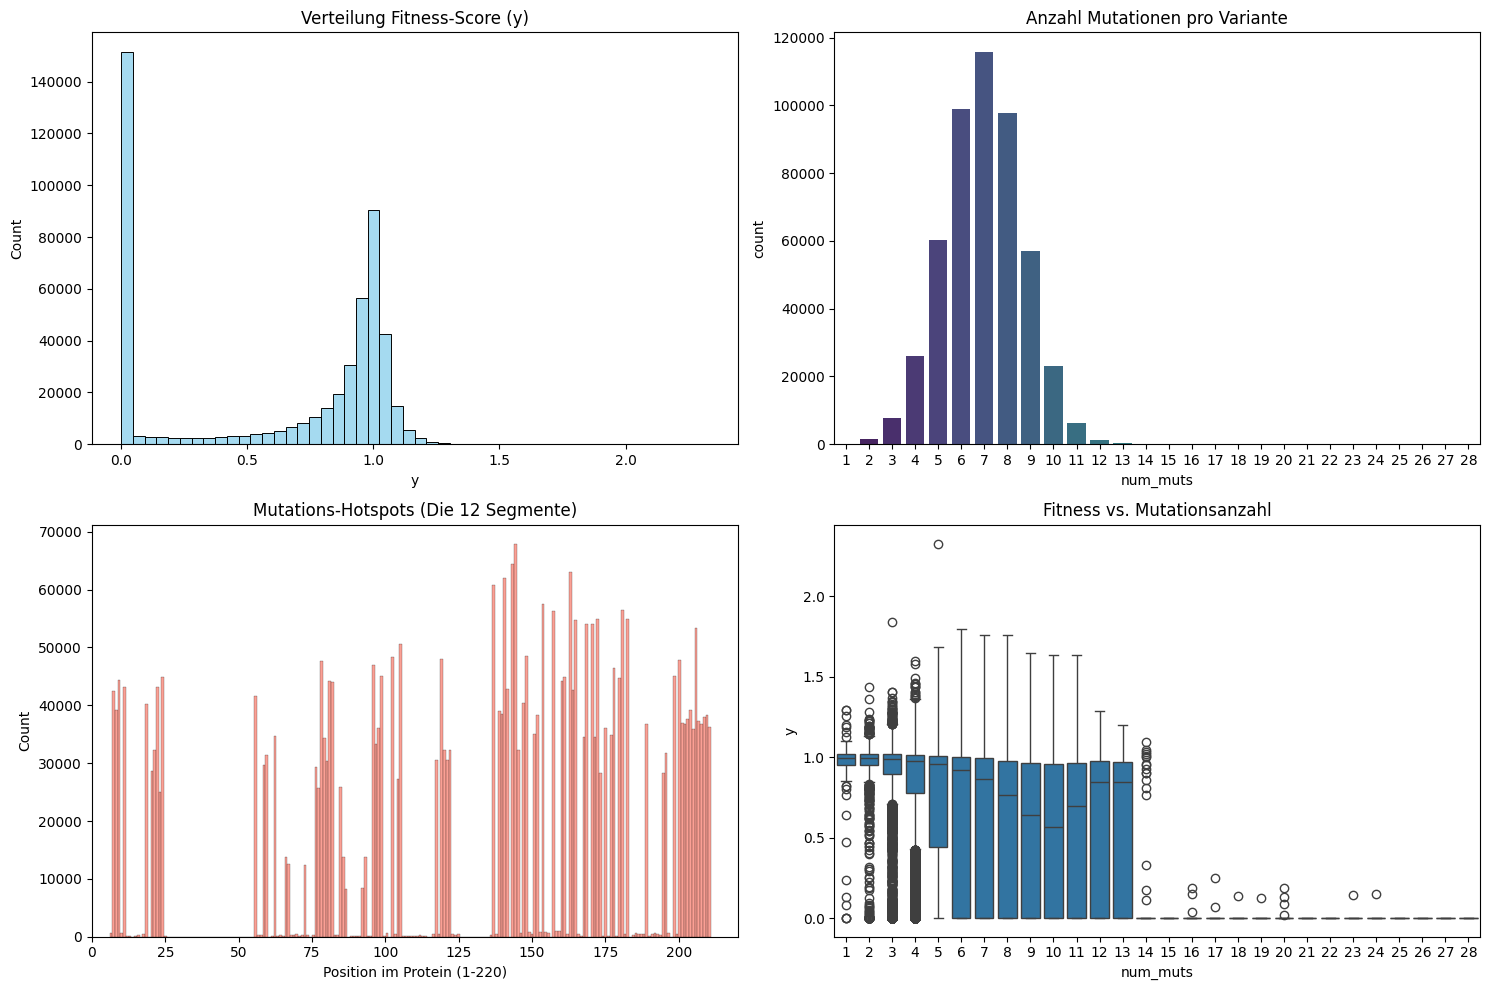

In [10]:
# 3. Plots erstellen
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Plot A: Fitness (y)
if not pg['y'].dropna().empty:
    sns.histplot(pg['y'].dropna(), bins=50, ax=axes[0,0], color='skyblue')
    axes[0,0].set_title('Verteilung Fitness-Score (y)')
else:
    axes[0,0].text(0.5, 0.5, 'Keine Daten in Spalte y', ha='center')

# Plot B: Anzahl Mutationen
sns.countplot(data=pg, x='num_muts', ax=axes[0,1], palette='viridis')
axes[0,1].set_title('Anzahl Mutationen pro Variante')

# Plot C: Positionen (Das Herzstück für die Segmente)
all_pos = [p for sublist in pg['pos_list'] for p in sublist]
if all_pos:
    sns.histplot(all_pos, bins=220, ax=axes[1,0], color='salmon')
    axes[1,0].set_xlim(0, 220)
    axes[1,0].set_title('Mutations-Hotspots (Die 12 Segmente)')
    axes[1,0].set_xlabel('Position im Protein (1-220)')
else:
    axes[1,0].text(0.5, 0.5, 'Keine Positionen gefunden', ha='center')

# Plot D: Score vs Mutationen
if not pg['y'].dropna().empty:
    sns.boxplot(data=pg, x='num_muts', y='y', ax=axes[1,1])
    axes[1,1].set_title('Fitness vs. Mutationsanzahl')

plt.tight_layout()
plt.show()

In [11]:
# Test-Ausgabe: Zeige die ersten 5 extrahierten Positions-Listen
print("Check der Extraktion (Spalte mutant -> pos_list):")
print(pg[['mutant', 'pos_list', 'num_muts']].head())

Check der Extraktion (Spalte mutant -> pos_list):
                                     mutant                          pos_list  \
0           A6E:L7S:V8I:I11D:A20S:I21L:K24D         [6, 7, 8, 11, 20, 21, 24]   
1            A6S:L7F:V8I:K9R:I11N:I21L:S22G          [6, 7, 8, 9, 11, 21, 22]   
2       A6S:L7F:V8I:K9S:I11N:I19V:L23I:K24N      [6, 7, 8, 9, 11, 19, 23, 24]   
3  A6S:L7F:V8I:K9S:I19V:A20S:S22C:L23I:K24D  [6, 7, 8, 9, 19, 20, 22, 23, 24]   
4       A6S:L7F:V8I:K9S:I19V:I21L:S22C:K24E      [6, 7, 8, 9, 19, 21, 22, 24]   

   num_muts  
0         7  
1         7  
2         8  
3         9  
4         8  


In [12]:
# 3. Segment-Rekonstruktion (Bonus)
# Wir gruppieren nach der Start-Position, um die 12 Segmente zu finden
segment_counts = pg.groupby('min_pos').size().reset_index(name='count')
print("Top Start-Positionen (identifiziert die Segmente):")
print(segment_counts.sort_values('count', ascending=False).head(12))

Top Start-Positionen (identifiziert die Segmente):
     min_pos  count
71       137  60661
111      181  56314
54        96  46975
1          7  41857
22        56  41688
102      171  34464
79       145  31635
103      172  25971
81       147  22002
32        66  13775
113      183  13560
82       148  12150


# GEO: AAseq-Fragmente auf WT mappen → Positions-Set pro Segment

In [49]:
his3_wt = "MTEQKALVKRITNETKIQIAISLKGGPLAIEHSIFPEKEAEAVAEQATQSQVINVHTGIGFLDHMIHALAKHSGWSLIVECIGDLHIDDHHTTEDCGIALGQAFKEALGAVRGVKRFGSGFAPLDEALSRAVVDLSNRPYAVVELGLQREKVGDLSCEMIPHFLESFAEASRITLHVDCLRGKNDHHRSESAFKALAVAIREATSPNGTNDVPSTKGVLM"

In [50]:
import re
import pandas as pd

mut_re = re.compile(r"([A-Z])(\d+)([A-Z])")

def parse_positions(mutant: str):
    s = str(mutant).strip()
    if s == "" or s.lower() == "nan":
        return []
    parts = re.split(r"[,:; ]+", s)
    pos = []
    for p in parts:
        m = mut_re.fullmatch(p)
        if m:
            pos.append(int(m.group(2)))
    return pos

pg["mut_pos"] = pg["mutant"].apply(parse_positions)
pg["n_mut"] = pg["mut_pos"].apply(len)


## GEO: AAseq-Fragmente auf WT mappen → Positions-Set pro Segment

In [51]:
import os
import numpy as np

def aaseq_fragments(aaseq: str, min_len: int = 4):
    parts = [p for p in str(aaseq).strip("_").split("_") if p]
    return [p for p in parts if len(p) >= min_len]

def best_window_match(fragment: str, wt: str):
    """Return (mismatches, start_0based) for best sliding-window match."""
    L = len(fragment)
    if L == 0 or L > len(wt):
        return None
    best = None
    for start in range(0, len(wt) - L + 1):
        window = wt[start:start+L]
        mism = sum(a != b for a, b in zip(fragment, window))
        if best is None or mism < best[0]:
            best = (mism, start)
            if mism == 0:
                break
    return best  # (mism, start)

def map_aaseq_to_positions(aaseq: str, wt: str, max_mismatch_frac: float = 0.25):
    """
    Map AAseq (underscore-separated fragments) onto WT by approximate substring matching.
    Returns: (pos_set, mismatch_total, matched_len_total)
    """
    pos_set = set()
    mism_total = 0
    len_total = 0

    for frag in aaseq_fragments(aaseq, min_len=4):
        m = best_window_match(frag, wt)
        if m is None:
            continue
        mism, start = m
        if mism / len(frag) > max_mismatch_frac:
            continue  # zu schlechter Match
        mism_total += mism
        len_total += len(frag)
        # 1-based Positionen
        pos_set.update(range(start + 1, start + 1 + len(frag)))

    return pos_set, mism_total, len_total

def build_geo_segment_possets(segment_folder: str, wt: str, sample_n: int = 1000, top_k: int = 50,
                              max_mismatch_frac: float = 0.25):
    """
    Für jedes Sxx file: sample AAseqs, score sie nach total mismatch, nehme top_k und union der Positions.
    """
    seg_possets = {}
    seg_qc = {}

    for fn in sorted(os.listdir(segment_folder)):
        m = re.search(r"S\d+", fn)
        if not m:
            continue
        seg_id = m.group()  # "S01" etc

        df = pd.read_csv(os.path.join(segment_folder, fn), sep="\t")
        df.columns = [c.strip() for c in df.columns]
        if "AAseq" not in df.columns:
            continue

        aaseqs = df["AAseq"].dropna().astype(str)
        if len(aaseqs) == 0:
            continue

        aaseqs = aaseqs.sample(n=min(sample_n, len(aaseqs)), random_state=1)

        scored = []
        for a in aaseqs:
            pos_set, mism_total, len_total = map_aaseq_to_positions(a, wt, max_mismatch_frac=max_mismatch_frac)
            if len(pos_set) == 0 or len_total == 0:
                continue
            # score: weniger mismatches besser, mehr abgedeckte Positionen besser
            scored.append((mism_total / len_total, -len(pos_set), pos_set))

        if not scored:
            # keine brauchbaren Matches
            seg_possets[seg_id] = set()
            seg_qc[seg_id] = {"n_matches": 0}
            continue

        scored.sort(key=lambda x: (x[0], x[1]))  # mismatch_frac asc, coverage desc
        top = scored[:min(top_k, len(scored))]

        union_pos = set()
        mismatch_fracs = []
        for mf, _, pset in top:
            union_pos |= pset
            mismatch_fracs.append(mf)

        seg_possets[seg_id] = union_pos
        seg_qc[seg_id] = {
            "n_matches": len(top),
            "mean_mismatch_frac": float(np.mean(mismatch_fracs)),
            "min_pos": int(min(union_pos)) if union_pos else None,
            "max_pos": int(max(union_pos)) if union_pos else None,
            "n_pos": int(len(union_pos)),
        }

    return seg_possets, pd.DataFrame(seg_qc).T.sort_index()


In [52]:
segment_folder = "./data/yeast_his3/"  # deine GEO-Segment-TXTs
seg_possets, geo_qc = build_geo_segment_possets(
    segment_folder, his3_wt,
    sample_n=1000, top_k=50,
    max_mismatch_frac=0.25
)

geo_qc


,n_matches,mean_mismatch_frac,min_pos,max_pos,n_pos
S01,50.0,0.116277,106.0,135.0,30.0
S02,50.0,0.138409,135.0,163.0,29.0
S03,50.0,0.135086,145.0,170.0,26.0
S04,50.0,0.120000,171.0,200.0,30.0
S05,50.0,0.122319,2.0,211.0,35.0
S06,50.0,0.119165,96.0,125.0,30.0
S07,50.0,0.091746,66.0,95.0,30.0
S08,50.0,0.113454,56.0,85.0,30.0
S09,50.0,0.221000,36.0,55.0,20.0
S10,50.0,0.200868,30.0,47.0,18.0


# proteingym varianten einem geo segment zuordnen

In [53]:
def assign_geo_segment(mut_pos):
    if not mut_pos:
        return "WT"
    pos = set(mut_pos)

    # Kandidaten: Segment enthält alle Positionen
    cands = [sid for sid, pset in seg_possets.items() if pset and pos.issubset(pset)]
    if len(cands) == 1:
        return cands[0]
    if len(cands) > 1:
        return "AMBIG"

    # Nicht vollständig in einem Segment: liegt es in mehreren Segmenten verteilt?
    overlaps = [sid for sid, pset in seg_possets.items() if pset and len(pos & pset) > 0]
    if len(overlaps) > 1:
        return "MULTI"
    return "UNASSIGNED"

pg["geo_segment"] = pg["mut_pos"].apply(assign_geo_segment)
pg["geo_segment"].value_counts()


geo_segment
S02      83847
S05      75003
S03      71871
S06      65141
S04      64966
S08      58382
S12      57476
S07      16355
AMBIG     2879
S11        188
S09         29
Name: count, dtype: int64

In [54]:
def assign_geo_segment_tiebreak(mut_pos):
    if not mut_pos:
        return "WT"
    pos = set(mut_pos)
    cands = [(sid, len(pset)) for sid, pset in seg_possets.items() if pset and pos.issubset(pset)]
    if len(cands) == 1:
        return cands[0][0]
    if len(cands) > 1:
        # kleinster Positionsraum gewinnt
        return sorted(cands, key=lambda x: x[1])[0][0]
    overlaps = [sid for sid, pset in seg_possets.items() if pset and len(pos & pset) > 0]
    if len(overlaps) > 1:
        return "MULTI"
    return "UNASSIGNED"

pg["geo_segment"] = pg["mut_pos"].apply(assign_geo_segment_tiebreak)
pg["geo_segment"].value_counts().head(20)


geo_segment
S02    83847
S05    75003
S03    72147
S06    65141
S04    65037
S08    58382
S12    57820
S07    18473
S11      214
S01       44
S09       29
Name: count, dtype: int64

In [55]:
# geo_counts: dict "S01"->125915 etc (hast du aus den GEO files)
order = [sid for sid,_ in sorted(geo_counts.items(), key=lambda x: x[1], reverse=True)]

disjoint = {}
used = set()
for sid in order:
    pset = set(seg_possets[sid])
    pset = pset - used
    disjoint[sid] = pset
    used |= pset

for sid in [f"S{i:02d}" for i in range(1,13)]:
    print(sid, "orig", len(seg_possets[sid]), "disjoint", len(disjoint[sid]))

NameError: name 'geo_counts' is not defined

In [ ]:
def assign_segment_disjoint(mut_pos):
    if not mut_pos:
        return "WT"
    pos = set(mut_pos)
    cands = [sid for sid, pset in disjoint.items() if pset and pos.issubset(pset)]
    if len(cands) == 1:
        return cands[0]
    if len(cands) > 1:
        return "AMBIG"
    return "UNASSIGNED"

pg["geo_segment_disjoint"] = pg["mut_pos"].apply(assign_segment_disjoint)
pg["geo_segment_disjoint"].value_counts()


# schnelltest

In [37]:
# Anteil zugeordnet (S01..S12)
assigned = pg["geo_segment"].str.match(r"^S\d+").mean()
print("assigned fraction:", assigned)

# Wie viele sind MULTI / UNASSIGNED?
print(pg["geo_segment"].value_counts().head(20))

# Sind die zugeordneten Varianten wirklich auf Segment-Positionen beschränkt?
def check_subset_rate(seg_id):
    rows = pg[pg["geo_segment"] == seg_id]
    if len(rows) == 0:
        return None
    pset = seg_possets[seg_id]
    ok = rows["mut_pos"].apply(lambda mp: set(mp).issubset(pset)).mean()
    return float(ok)

for sid in sorted([k for k in seg_possets.keys() if k.startswith("S")]):
    r = check_subset_rate(sid)
    if r is not None:
        print(sid, "subset_rate", r, "n", int((pg["geo_segment"]==sid).sum()))


assigned fraction: 1.0
geo_segment
S02    83847
S05    75003
S03    72147
S06    65141
S04    65037
S08    58382
S12    57820
S07    18473
S11      214
S01       44
S09       29
Name: count, dtype: int64
S01 subset_rate 1.0 n 44
S02 subset_rate 1.0 n 83847
S03 subset_rate 1.0 n 72147
S04 subset_rate 1.0 n 65037
S05 subset_rate 1.0 n 75003
S06 subset_rate 1.0 n 65141
S07 subset_rate 1.0 n 18473
S08 subset_rate 1.0 n 58382
S09 subset_rate 1.0 n 29
S11 subset_rate 1.0 n 214
S12 subset_rate 1.0 n 57820


In [33]:
import os, re
fns = sorted(os.listdir(segment_folder))
print([re.search(r"S\d+", f).group() for f in fns if re.search(r"S\d+", f)])


['S01', 'S02', 'S03', 'S04', 'S05', 'S06', 'S07', 'S08', 'S09', 'S10', 'S11', 'S12']


In [38]:
# wie viele ProteinGym-Varianten würden in S10 passen?
pset10 = seg_possets["S10"]
cand10 = pg["mut_pos"].apply(lambda mp: len(mp)>0 and set(mp).issubset(pset10)).sum()
print("S10 subset candidates:", cand10)

# Gibt es überhaupt Mutationen in S10-Positionen?
mut_in_10 = pg["mut_pos"].apply(lambda mp: any(p in pset10 for p in mp)).sum()
print("Variants touching S10 positions:", mut_in_10)


S10 subset candidates: 0
Variants touching S10 positions: 0


In [39]:
for sid in [f"S{i:02d}" for i in range(1,13)]:
    pset = seg_possets[sid]
    print(sid, len(pset), (min(pset), max(pset)) if pset else None)


S01 30 (106, 135)
S02 29 (135, 163)
S03 26 (145, 170)
S04 30 (171, 200)
S05 35 (2, 211)
S06 30 (96, 125)
S07 30 (66, 95)
S08 30 (56, 85)
S09 20 (36, 55)
S10 18 (30, 47)
S11 22 (13, 205)
S12 19 (6, 24)


In [40]:
pg.groupby("geo_segment")["n_mut"].describe().loc[[f"S{i:02d}" for i in range(1,13)]]


KeyError: "['S10'] not in index"

In [41]:
print("ProteinGym total rows:", len(pg))
print("Unique mutants:", pg["mutant"].nunique())
print("Unique sequences:", pg["sequence"].nunique())


ProteinGym total rows: 496137
Unique mutants: 496137
Unique sequences: 496137


In [42]:
import os
import pandas as pd

segment_folder = "./data/yeast_his3/"
rows = []
for fn in sorted(os.listdir(segment_folder)):
    if not fn.startswith("S") or "fitness" not in fn:
        continue
    path = os.path.join(segment_folder, fn)
    df = pd.read_csv(path, sep="\t")
    rows.append({"file": fn, "n_rows": len(df)})

counts = pd.DataFrame(rows).sort_values("file")
counts


,file,n_rows
0,S01_fitness.txt,125915
1,S02_fitness.txt,122167
2,S03_fitness.txt,94031
3,S04_fitness.txt,69050
4,S05_fitness.txt,99891
5,S06_fitness.txt,83625
6,S07_fitness.txt,26364
7,S08_fitness.txt,73781
8,S09_fitness.txt,81497
9,S10_fitness.txt,79905


In [45]:
pd.DataFrame(rows).sort_values("n_rows", ascending=False)

,file,n_rows
0,S01_fitness.txt,125915
1,S02_fitness.txt,122167
4,S05_fitness.txt,99891
2,S03_fitness.txt,94031
5,S06_fitness.txt,83625
8,S09_fitness.txt,81497
9,S10_fitness.txt,79905
7,S08_fitness.txt,73781
3,S04_fitness.txt,69050
11,S12_fitness.txt,63255


In [46]:
def touch_count(sid):
    pset = seg_possets[sid]
    return pg["mut_pos"].apply(lambda mp: any(p in pset for p in mp)).sum()

def subset_count(sid):
    pset = seg_possets[sid]
    return pg["mut_pos"].apply(lambda mp: len(mp)>0 and set(mp).issubset(pset)).sum()

for sid in [f"S{i:02d}" for i in range(1,13)]:
    print(sid, "touch", touch_count(sid), "subset", subset_count(sid), "posset_size", len(seg_possets[sid]))


S01 touch 64063 subset 44 posset_size 30
S02 touch 155690 subset 84123 posset_size 29
S03 touch 154454 subset 72147 posset_size 26
S04 touch 137429 subset 65037 posset_size 30
S05 touch 138431 subset 75100 posset_size 35
S06 touch 65185 subset 65185 posset_size 30
S07 touch 76823 subset 18473 posset_size 30
S08 touch 76708 subset 60500 posset_size 30
S09 touch 29 subset 29 posset_size 20
S10 touch 0 subset 0 posset_size 18
S11 touch 130452 subset 558 posset_size 22
S12 touch 58005 subset 57820 posset_size 19


In [47]:
import itertools

for a,b in itertools.combinations([f"S{i:02d}" for i in range(1,13)], 2):
    inter = len(seg_possets[a] & seg_possets[b])
    if inter > 0:
        print(a,b,"overlap",inter)


S01 S02 overlap 1
S01 S06 overlap 20
S02 S03 overlap 19
S04 S05 overlap 20
S05 S11 overlap 5
S07 S08 overlap 20
S09 S10 overlap 12
S11 S12 overlap 12


In [57]:
# counts: DataFrame mit Spalten file, n_rows
counts2 = counts.copy()
counts2["seg_id"] = counts2["file"].str.extract(r"(S\d+)")
geo_counts = dict(zip(counts2["seg_id"], counts2["n_rows"]))

geo_counts



{'S01': 125915,
 'S02': 122167,
 'S03': 94031,
 'S04': 69050,
 'S05': 99891,
 'S06': 83625,
 'S07': 26364,
 'S08': 73781,
 'S09': 81497,
 'S10': 79905,
 'S11': 37167,
 'S12': 63255}

In [58]:
order = [sid for sid, _ in sorted(geo_counts.items(), key=lambda x: x[1], reverse=True)]
order


['S01',
 'S02',
 'S05',
 'S03',
 'S06',
 'S09',
 'S10',
 'S08',
 'S04',
 'S12',
 'S11',
 'S07']

In [59]:
disjoint = {}
used = set()
for sid in order:
    pset = set(seg_possets.get(sid, set()))
    pset = pset - used
    disjoint[sid] = pset
    used |= pset

for sid in [f"S{i:02d}" for i in range(1,13)]:
    print(sid, "orig", len(seg_possets.get(sid,set())), "disjoint", len(disjoint.get(sid,set())))


S01 orig 30 disjoint 30
S02 orig 29 disjoint 28
S03 orig 26 disjoint 7
S04 orig 30 disjoint 10
S05 orig 35 disjoint 35
S06 orig 30 disjoint 10
S07 orig 30 disjoint 10
S08 orig 30 disjoint 30
S09 orig 20 disjoint 20
S10 orig 18 disjoint 6
S11 orig 22 disjoint 5
S12 orig 19 disjoint 19


In [60]:
def assign_segment_disjoint(mut_pos):
    if not mut_pos:
        return "WT"
    pos = set(mut_pos)
    cands = [sid for sid, pset in disjoint.items() if pset and pos.issubset(pset)]
    if len(cands) == 1:
        return cands[0]
    if len(cands) > 1:
        return "AMBIG"
    return "UNASSIGNED"

pg["geo_segment_disjoint"] = pg["mut_pos"].apply(assign_segment_disjoint)
pg["geo_segment_disjoint"].value_counts()


geo_segment_disjoint
UNASSIGNED    215310
S02            84123
S05            75100
S08            60500
S12            57820
S04             1635
S06             1122
S03              304
S07              147
S01               44
S09               29
S11                3
Name: count, dtype: int64